In [240]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re 
import string
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from contractions import fix
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix
from imblearn.over_sampling import SMOTE

In [180]:
stop_word=set(stopwords.words('english'))
simple=SimpleImputer(strategy='most_frequent')
lemmatizer=WordNetLemmatizer()
vectorizer=TfidfVectorizer()
encoder=LabelEncoder()
model=RandomForestClassifier(n_estimators=300)
smote=SMOTE(sampling_strategy='auto')

In [3]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [181]:
df=pd.read_csv('C:/Users/DELL/Downloads/sentiment.csv',encoding='latin1')

In [182]:
df.head()

,textID,text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,f87dea47db,Last session of the day http://twitpic.com/67ezh,neutral,morning,0-20,Afghanistan,38928346.0,652860.0,60.0
1,96d74cb729,Shanghai is also really exciting (precisely -...,positive,noon,21-30,Albania,2877797.0,27400.0,105.0
2,eee518ae67,"Recession hit Veronique Branquinho, she has to...",negative,night,31-45,Algeria,43851044.0,2381740.0,18.0
3,01082688c6,happy bday!,positive,morning,46-60,Andorra,77265.0,470.0,164.0
4,33987a8ee5,http://twitpic.com/4w75p - I like it!!,positive,noon,60-70,Angola,32866272.0,1246700.0,26.0


In [183]:
df.drop(['Time of Tweet','Age of User','Country','textID','Population -2020','Land Area (Km²)','Density (P/Km²)'],axis=1,inplace=True)

In [184]:
df.sample(80)

,text,sentiment
1059,"Home, good night world",positive
479,"I could, but that would require today not to ...",neutral
1402,Why am I always the one on time. They are alwa...,negative
1739,me to mi sausage,neutral
2537,"Have a cold one for me, I`m just off to work now",neutral
...,...,...
3379,I`m feeling higher than Mt Everest,positive
815,Wango tango!!! Good night all,neutral
2771,moving offices I`m going to miss you Hollywood.,negative
3199,"I`ve made a game for you, Stephen- http://tin...",neutral


In [185]:
df['sentiment'].value_counts()

sentiment
neutral     1430
positive    1103
negative    1001
Name: count, dtype: int64

In [186]:
df.isnull().sum()

text         1281
sentiment    1281
dtype: int64

In [187]:
df['text']=simple.fit_transform(df[['text']]).ravel()
df['sentiment']=simple.fit_transform(df[['sentiment']]).ravel()

In [188]:
df.isnull().sum()

text         0
sentiment    0
dtype: int64

In [189]:
df['text'][3813]

'    - brief interruption- brb. goodnight if i don`t catch u again later. gotta ck something'

In [190]:
df['sentiment'][3813]

'neutral'

In [191]:
print(df['text'][4620])
print(df['sentiment'][4620])

    - brief interruption- brb. goodnight if i don`t catch u again later. gotta ck something
neutral


In [192]:
df['sentiment'].value_counts()

sentiment
neutral     2711
positive    1103
negative    1001
Name: count, dtype: int64

In [197]:
df.sample(50)

,text,sentiment
3895,- brief interruption- brb. goodnight if i ...,neutral
1809,"loving the shoes perez, looking fine as alway...",positive
742,Awwww i`ve got some photos of cute bunnies,positive
2311,"I can`t say I`ve tried, but then again, I hav...",neutral
2544,the AC tix are actually $20 but the show is s...,negative
4261,- brief interruption- brb. goodnight if i ...,neutral
114,bahah sadly I am not,negative
425,Thank you! You should know that I am both hap...,neutral
3064,Good Morning people!!! Have a great day,positive
2102,Hows that possible? No rain forecast for Pinkp...,neutral


In [196]:
df.isnull().sum()

text         0
sentiment    0
dtype: int64

In [198]:
df.head()

,text,sentiment
0,Last session of the day http://twitpic.com/67ezh,neutral
1,Shanghai is also really exciting (precisely -...,positive
2,"Recession hit Veronique Branquinho, she has to...",negative
3,happy bday!,positive
4,http://twitpic.com/4w75p - I like it!!,positive


In [199]:
df.shape

(4815, 2)

In [200]:
def clean_text(text):
    text=fix(text)
    text=str(text).lower()
    text=re.sub(r'<.*?>','',text)
    text=re.sub(r'\d+','NUM',text)
    text=re.sub(r'https?://\S+|www\.\S+','',text)
    text=text.translate(str.maketrans('','',string.punctuation))
    words=word_tokenize(text)
    improve_text=[lemmatizer.lemmatize(word) for word in words if word not in stop_word]
    return " ".join(improve_text)

In [201]:
df.loc[:,'text']=df['text'].apply(clean_text)

In [202]:
df.sample(40)

,text,sentiment
859,buckley good morning sunny londonsounds like o...,positive
1943,yo thomas thanks follow social medium director...,positive
2425,joined twitter hehe,neutral
1123,youuuure aaass aaass loooool,negative
379,lucky thats awesome,positive
2800,tiiiired sleep,negative
4244,brief interruption brb goodnight dont catch la...,neutral
3594,brief interruption brb goodnight dont catch la...,neutral
510,sure continue tweet conf call worrying cat bee,negative
3811,brief interruption brb goodnight dont catch la...,neutral


In [203]:
y=encoder.fit_transform(df['sentiment'])

In [204]:
pd.Series(y).value_counts()

1    2711
2    1103
0    1001
Name: count, dtype: int64

In [205]:
y.shape

(4815,)

<Axes: title={'center': 'before use SMOTE'}>

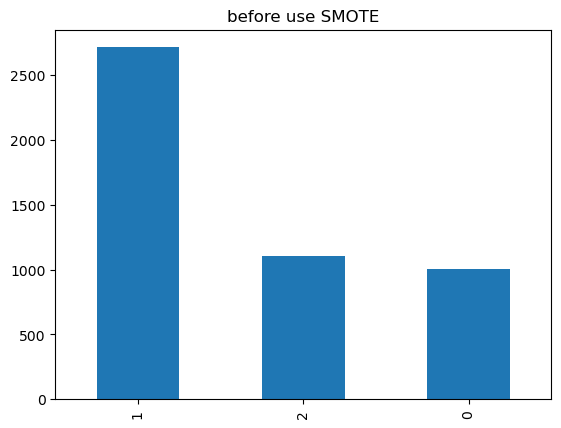

In [243]:
pd.Series(y).value_counts().plot(kind='bar',title='before use SMOTE')

In [206]:
X=vectorizer.fit_transform(df['text']).toarray()

In [207]:
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(4815, 6607))

In [208]:
X_balanced,y_balanced=smote.fit_resample(X,y)

In [209]:
print(X_balanced.shape,y_balanced.shape)

(8133, 6607) (8133,)


In [210]:
pd.Series(y_balanced).value_counts()

1    2711
2    2711
0    2711
Name: count, dtype: int64

<Axes: title={'center': 'after use SMOTE'}>

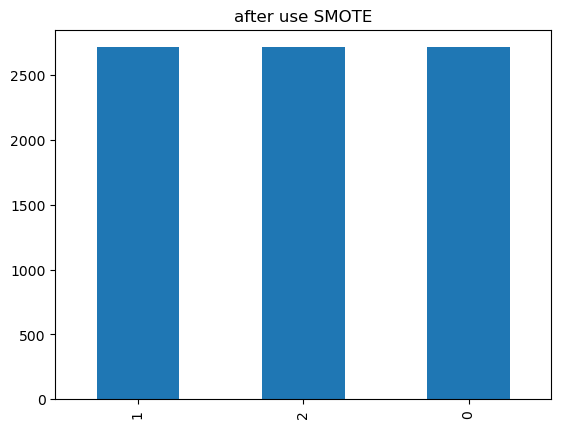

In [245]:
pd.Series(y_balanced).value_counts().plot(kind='bar',title='after use SMOTE')

In [211]:
X_train,X_test,y_train,y_test=train_test_split(X_balanced,y_balanced,test_size=0.2,random_state=42)

In [212]:
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(6506, 6607) (1627, 6607) (6506,) (1627,)


In [213]:
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print(f'Accuracy score : {accuracy_score(y_test,y_pred)}')
print(f'Precision score: {precision_score(y_test,y_pred,average=None)}')
print(f'Confusion matrix:{confusion_matrix(y_test,y_pred)}')

Accuracy score : 0.8715427166564229
Precision score: [0.88764045 0.825      0.9043152 ]
Confusion matrix:[[474  71   9]
 [ 57 462  42]
 [  3  27 482]]


In [215]:
print(f'Train Accuracy :{model.score(X_train,y_train)}')
print(f'Test Accuracy :{model.score(X_test,y_test)}')

Train Accuracy :0.9995388871810637
Test Accuracy :0.8715427166564229


In [216]:
def prediction (text):
    text=clean_text(text)
    text_vector=vectorizer.transform([text])
    y_pred=model.predict(text_vector)
    if y_pred==1:
        print("Neutral")
    elif y_pred==2:
        print("Positive")
    elif y_pred==0:
        print("Negative")

# Positive

In [217]:
prediction('Product is Amazing, love it!')

Positive


In [220]:
prediction('I absolutely love this product!.')

Positive


In [221]:
prediction('Best restaurant in town, highly recommend!')

Positive


In [222]:
prediction('the team did an amazing job!')

Positive


In [224]:
prediction('Fantastic experience, exceeded expectations!')

Neutral


# Negative

In [239]:
prediction('The food at that restaurant was disgusting.')

Negative


In [226]:
prediction('Worst customer support ever.')

Negative


In [235]:
prediction('Their delivery was super late again.')

Neutral


In [228]:
prediction('Terrible food, never going back.')

Negative


In [234]:
prediction('The food was cold and tasteless.')

Negative


# Neutral

In [219]:
prediction('Okay, it is fine I guess.')

Neutral


In [230]:
prediction("It's an okay movie, nothing special.")

Neutral


In [231]:
prediction("The weather is fine, I guess.")

Neutral


In [232]:
prediction('Nothing Exciting, but does the job.')

Neutral


In [233]:
prediction('Average experience, nothing to complain.')

Neutral
